# Gradient Boosting Model: XGBoost

In [7]:
# Settings

import os
import json
import pandas as pd
import numpy as np
import torch
import optuna
from pathlib import Path

from numpy import f2py
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, fbeta_score, f1_score, recall_score, precision_score
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix


SEED = 1234
TUNE = True
TUNE_PROB = False
TUNE_SAVE = True
TUNE_METRIC = 'f1' # recall/auc/f1/f2
TUNE_OUTPUT = f'xgboost_params_{TUNE_METRIC}.json'
MODEL_OUTPUT = f'xgboost_model_{TUNE_METRIC}.json'
MODEL_SAVE = True
MODEL_LOAD = True
N_TRIALS = 200

In [8]:
# Load data
X_train, X_val, X_test, y_train, y_val, y_test = DataLoader().fetch_data(version='final_onehot')

# Remove ID and drug (not grouped) columns
id_cols = [c for c in X_train.columns if 'encounter_id' in c or 'patient_nbr' in c]
drug_cols = [c for c in X_train.columns if 'prescript' in c and (('Up' in c) or ('Down' in c) or ('Steady' in c) or ('No' in c))]
drug_group_cols = [c for c in X_train.columns if 'prescript' in c and (('prescribed' in c) or ('change' in c))]
drop_cols = id_cols + drug_cols
X_train = X_train.drop(drop_cols, axis=1)
X_val = X_val.drop(drop_cols, axis=1)
X_test = X_test.drop(drop_cols, axis=1)

# Modify special characters in column names for xgboost tuning
cols_update = [c.replace('[', '(').replace(')', ')').replace('<', 'lt').replace('>', 'gt') for c in X_train.columns]
X_train.columns = cols_update
X_val.columns = cols_update
X_test.columns = cols_update

# Convert input to tensors for gpu
X_train_t = torch.tensor(X_train.values, dtype=torch.float32, device='cuda')
X_val_t = torch.tensor(X_val.values, dtype=torch.float32, device='cuda')
y_train_t = torch.tensor(y_train.values, dtype=torch.float32, device='cuda')
y_val_t = torch.tensor(y_val.values, dtype=torch.float32, device='cuda')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


### Hyperparameter tuning

- Use the same evaluation score metric (recall) for hyperparameter tuning.
- Suggest overfitting using a 10% discrepancy between training and validation accuracy.
- If overfitting is suggested, force to metric to 0 to skip the trail output.

In [3]:
# Define objective function

def objective(trial):
    """
    Hyperparameter tuning objective function.

    Args:
        trial: Tuning hyperparameter trial

    Returns:
        Assessment score
    """
    params                 = {
        'n_estimators'    : trial.suggest_int('n_estimators'      , 300  , 2000),
        'max_depth'       : trial.suggest_int('max_depth'         , 5    , 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 10   , 50),
        'subsample'       : trial.suggest_float('subsample'       , 0.2  , 0.8),
        'learning_rate'   : trial.suggest_float('learning_rate'   , 0.001, 0.1  , log = True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2  , 0.8),
        'gamma'           : trial.suggest_float('gamma'           , 0    , 10),
        'reg_alpha'       : trial.suggest_float('reg_alpha'       , 0.001, 10   , log = True),
        'reg_lambda'      : trial.suggest_float('reg_lambda'      , 0.001, 10   , log = True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0  , 1.3),
        'objective'       : 'binary:logistic',
        'eval_metric'     : 'auc',
        'tree_method'     : 'hist',
        'device'          : 'cuda',
        'random_state'    : SEED,
        'n_jobs'          : -1,
    }

    # Probability threshold
    PROB_TH = trial.suggest_float('prob_th', 0.45, 0.55) if TUNE_PROB else 0.5

    # Fit the model
    model = XGBClassifier(**params)
    model.fit(X_train_t,
              y_train_t,
              eval_set=[(X_val_t, y_val_t)],
              verbose=False
              )

    y_pred_train = (model.predict_proba(X_train_t)[:, 1] >= PROB_TH) * 1
    y_pred_val = (model.predict_proba(X_val_t)[:, 1] >= PROB_TH) * 1

    if TUNE_METRIC == 'recall':

        # traing set
        recall_tr, _, _, acc_tr, _ = \
        evaluate_predictions(true_values = y_train,
                             predictions = y_pred_train,
                             print_class_report = False)

        # validation set:
        recall_vl, _, _, acc_vl , _ = \
        evaluate_predictions(true_values = y_val,
                             predictions = y_pred_val,
                             print_class_report = False)

        # Force the trial to output minimum score if overfits
        if acc_tr - acc_vl > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        return recall_vl

    elif TUNE_METRIC == 'f1':

        acc_train = accuracy_score(y_train, y_pred_train)
        acc_val = accuracy_score(y_val, y_pred_val)
        if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        score = f1_score(y_val, y_pred_val)

        print('score:', score)
        print('recall:', recall_score(y_val, y_pred_val))
        print('precision:', precision_score(y_val, y_pred_val))
        print('accuracy:', accuracy_score(y_val, y_pred_val))
        return score

    elif TUNE_METRIC == 'f2':

        acc_train = accuracy_score(y_train, y_pred_train)
        acc_val = accuracy_score(y_val, y_pred_val)
        if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        score = fbeta_score(y_val, y_pred_val, beta=2)

        print('score:', score)
        print('recall:', recall_score(y_val, y_pred_val))
        print('precision:', precision_score(y_val, y_pred_val))
        print('accuracy:', accuracy_score(y_val, y_pred_val))
        return score

    elif TUNE_METRIC == 'auc':

        # Force the trial to output minimum score if overfits
        acc_train = accuracy_score(y_train, y_pred_train)
        acc_val = accuracy_score(y_val, y_pred_val)
        if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
            print(f"Warning: Possible overfitting")
            return 0

        score = roc_auc_score(y_val, y_pred_val)

        print('score:', score)
        print('recall:', recall_score(y_val, y_pred_val))
        print('precision:', precision_score(y_val, y_pred_val))
        print('accuracy:', accuracy_score(y_val, y_pred_val))
        return score


In [4]:
# Perform tuning and save the best parameters
if TUNE:
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1)
    print('Best Value:', study.best_value)
    print('Best Parameters:', study.best_params)

    if TUNE_SAVE:
        # Save output
        print('Save parameters to file:', TUNE_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'w') as f:
            json.dump(study.best_params, f)

[I 2026-07-13 17:00:05,185] A new study created in memory with name: no-name-61e01df5-83b9-4beb-8f98-08ee46bbeee8


score: 0.6293840781416064
recall: 0.6641033856669871
precision: 0.5981146594844171
accuracy: 0.6314359051789219


[I 2026-07-13 17:00:24,088] Trial 1 finished with value: 0.6293840781416064 and parameters: {'n_estimators': 340, 'max_depth': 6, 'min_child_weight': 29.659226592671946, 'subsample': 0.5550862147411526, 'learning_rate': 0.07296189627078992, 'colsample_bytree': 0.4417656520703327, 'gamma': 4.359077680368923, 'reg_alpha': 0.025542850685169136, 'reg_lambda': 0.08511491910559738, 'scale_pos_weight': 1.2594853970692603}. Best is trial 1 with value: 0.6293840781416064.


score: 0.6522906456424462
recall: 0.8173662287728293
precision: 0.5426889802864842
accuracy: 0.5893603100307011


[I 2026-07-13 17:00:32,016] Trial 4 finished with value: 0.6522906456424462 and parameters: {'n_estimators': 322, 'max_depth': 9, 'min_child_weight': 28.811059591472436, 'subsample': 0.362269652773766, 'learning_rate': 0.0016698859473998158, 'colsample_bytree': 0.5750925826816069, 'gamma': 9.530544080194696, 'reg_alpha': 0.00938465805001877, 'reg_lambda': 3.2403274210407145, 'scale_pos_weight': 1.2483378103244278}. Best is trial 4 with value: 0.6522906456424462.


...

score: 0.6569276071742706
recall: 0.9173341877603333
precision: 0.5116763969974979
accuracy: 0.5484926267049172
score: 0.6555428943512942
score: 0.6556566862979284
recall: 0.8601943821424757
recall: 0.8501548648937306
precision: 0.5295548688276678
accuracy: 0.574009763953898
precision: 0.533583590293605
accuracy: 0.5791937188585233
score: 0.6289137219369777
recall: 0.6672006835415999
precision: 0.594782443111492
accuracy: 0.6289697518747798
score: 0.6554471544715447
recall: 0.8610488091423689
precision: 0.5291067795497801
accuracy: 0.5734058080426796


[I 2026-07-13 17:06:05,821] Trial 193 finished with value: 0.6555428943512942 and parameters: {'n_estimators': 395, 'max_depth': 6, 'min_child_weight': 32.370873255379976, 'subsample': 0.3018832385228586, 'learning_rate': 0.001750687447931613, 'colsample_bytree': 0.2894069871992326, 'gamma': 0.6825446391020517, 'reg_alpha': 2.571027449691442, 'reg_lambda': 0.00791412935823635, 'scale_pos_weight': 1.2622263844907013}. Best is trial 59 with value: 0.6581853096495439.
[I 2026-07-13 17:06:05,876] Trial 199 finished with value: 0.6289137219369777 and parameters: {'n_estimators': 401, 'max_depth': 6, 'min_child_weight': 33.14831578163699, 'subsample': 0.3077297064766103, 'learning_rate': 0.014455073680096733, 'colsample_bytree': 0.29502360101980996, 'gamma': 4.957821953626747, 'reg_alpha': 1.4145348948358643, 'reg_lambda': 0.007022248518894254, 'scale_pos_weight': 1.260772332742835}. Best is trial 59 with value: 0.6581853096495439.
[I 2026-07-13 17:06:05,896] Trial 198 finished with value: 0

score: 0.6560197571516773
recall: 0.8511160952686105
precision: 0.5336860433967319
accuracy: 0.5793950374955962
score: 0.6554195159903362
recall: 0.8547474100181566
precision: 0.5314782839686545
accuracy: 0.5764759172580401
score: 0.6558170713540891
recall: 0.9404037167574495
precision: 0.5034593172851507
accuracy: 0.5348532890432331


[I 2026-07-13 17:06:06,253] Trial 195 finished with value: 0.6563459884506696 and parameters: {'n_estimators': 407, 'max_depth': 6, 'min_child_weight': 23.360058009645833, 'subsample': 0.3005957897866097, 'learning_rate': 0.001724962813773938, 'colsample_bytree': 0.2947511213420347, 'gamma': 0.7020004599023272, 'reg_alpha': 2.69384583228117, 'reg_lambda': 0.006968827786094328, 'scale_pos_weight': 1.262194813586411}. Best is trial 59 with value: 0.6581853096495439.


score: 0.6563459884506696
recall: 0.8558154437680231
precision: 0.5322837783977681
accuracy: 0.5776838290804771
Best Value: 0.6581853096495439
Best Parameters: {'n_estimators': 331, 'max_depth': 6, 'min_child_weight': 24.131462101975465, 'subsample': 0.20319514143274559, 'learning_rate': 0.0015650515234910231, 'colsample_bytree': 0.4926377214860383, 'gamma': 0.2935479848559571, 'reg_alpha': 1.6936656704538378, 'reg_lambda': 1.1365626981737442, 'scale_pos_weight': 1.2803438763848114}
Save parameters to file: xgboost_params_f1.json


### Model training with the best parameters

In [9]:
# Fit model
if not MODEL_LOAD:

    # Load parameters
    with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
        best_params = json.load(f)

    # Fit the model
    model = XGBClassifier(**best_params)
    model.fit(X_train,
              y_train,
              eval_set=[(X_val, y_val)],
              verbose=False
              )

    # Save model
    if MODEL_SAVE:
       model.save_model(os.path.join(os.getcwd(), MODEL_OUTPUT))

# Load model
else:
    model = XGBClassifier()
    model.load_model(os.path.join(os.getcwd(), MODEL_OUTPUT))

              precision    recall  f1-score   support

           0       0.74      0.30      0.42     10506
           1       0.53      0.88      0.66      9363

    accuracy                           0.57     19869
   macro avg       0.63      0.59      0.54     19869
weighted avg       0.64      0.57      0.53     19869

f1: 0.6597880423915217
recall: 0.8810210402648724
precision: 0.5273622298938755
accuracy: 0.5718455886053652


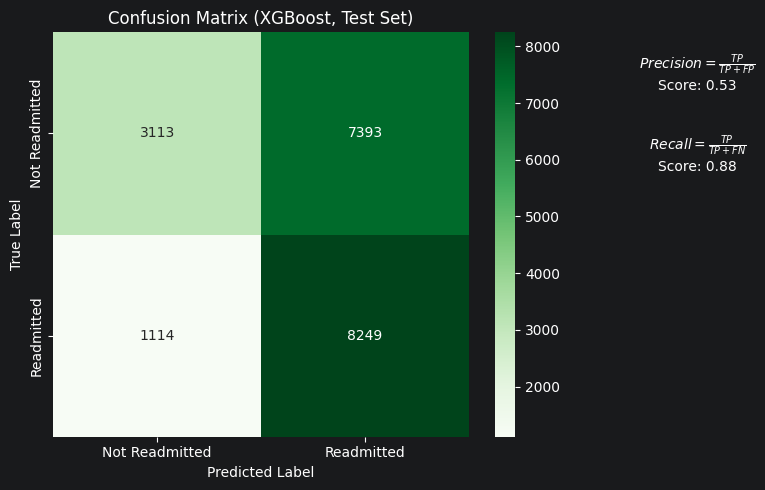

In [12]:
# Predict outcomes
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=y_test,
                     predictions=y_pred_test,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)

# confusion matrix-validation set
results_cm_test = plot_confusion_matrix(y_test,
                                        y_pred_test, #test set predictions
                                        class_names=['Not Readmitted', 'Readmitted'],
                                        fig_size=(8,5),
                                        title='Confusion Matrix (XGBoost, Test Set)',
                                        colour_map='Greens'
                                        )